In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from Bio.Seq import Seq
from evo.dataset import CherriesDataset, EncodedPEINTDataset, EncodedPEINTDiffDataset
from matplotlib import pyplot as plt
import seaborn as sns
from tqdm import tqdm

from plmr.data.datamodule import PLMRDataModule
from plmr.models.nets.peint import PEINT
from plmr.models.modules.peint_module import PEINTDiffModule
from plmr.models.frameworks.peint import load_from_new_checkpoint, load_peintdiff_from_checkpoint, PEINTDiffSampler, PEINTDiffGuidanceSampler, PEINTDiffLangevinSampler
from evo.phylogeny import df_to_ete3_tree

/scratch/users/stephen.lu/uv-envs/plm/lib/python3.10/site-packages/transformers/utils/hub.py:111: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
/scratch/users/stephen.lu/uv-envs/plm/lib/python3.10/site-packages/wandb/sdk/launch/builder/build.py:11: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [3]:
# Load trained models from checkpoints
ckpt_dir = Path("/accounts/projects/yss/stephen.lu/protevo/plmr/logs/train/runs")
ckpt_paths = {
    "heavy": ckpt_dir / "2025-08-08_15-36-04/checkpoints/epoch_089.ckpt",
    "light": ckpt_dir / "2025-08-10_11-57-18/checkpoints/epoch_042.ckpt",
    "joint": ckpt_dir / "2025-08-10_11-58-46/checkpoints/epoch_044.ckpt",
}
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# modules = {k: load_from_new_checkpoint(v, device) for k, v in ckpt_paths.items()}
# vocab = next(iter(modules.values())).net.vocab
module = load_from_new_checkpoint(ckpt_paths["joint"], device)
vocab = module.net.vocab

Using device: cuda


/accounts/projects/yss/stephen.lu/protevo/plmr/plmr/models/frameworks/peint.py:65: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map

In [ ]:
data_dir = Path("/accounts/projects/yss/stephen.lu/protevo/plmr/data")
edges_df = pd.read_csv(data_dir / "wyatt/indels/full_df.csv.gz", compression="gzip")
print(edges_df.shape)
family = "d4_203694-igk-203694"
edges_df = edges_df[edges_df.family == family]
print(edges_df.shape)

(64155, 48)
(239, 48)


In [5]:
tree = df_to_ete3_tree(edges_df[["parent_name", "child_name", "branch_length"]])
print(tree.get_ascii(compact=True))


                                                                    /Node13-AAACGGGTCATTCACT-1-1279069_contig_h
                                                              /Node12     \-CAGATCAAGGACACCA-1-1287171_contig_h
                                                             |      \-GCCTCTAAGACTGGGT-1-1287174_contig_h
                                                             |                        /Node18-ACATGGTAGGGCTTGA-1-1287170_contig_h
                                                             |                       |      \Node19-ATCACGAGTACCCAAT-1-1279069_contig_h
                                                        /Node11                 /Node17           \Node20-CTGAAGTGTGTTCTTT-1-1279078_contig_h
                                                       |     |            /Node16    |                  \-TGGGAAGTCATAACCG-1-1287171_contig_h
                                                       |     |           |     |      \-ACGTCAATCATCTGTT-1-1279080_cont

In [6]:
root_data = edges_df[edges_df.parent_name == "naive"].iloc[0][["parent_heavy_aa", "parent_light_aa"]]
root_heavy, root_light = root_data.parent_heavy_aa, root_data.parent_light_aa
root_seq = root_heavy + ("G" * 10) + root_light
print(f"Root AA sequence: {root_seq}")

Root AA sequence: EVQLVESGGGLVQPGGSLRLSCAASGFTFSSYEMNWVRQAPGKGLEWVSYISSSGSTIYYADSVKGRFTISRDNAKNSLYLQMNSLRAEDTAVYYCASGGYCTNGVCYTAEYFQHWGQGTLVTVSSGGGGGGGGGGDIQMTQSPSTLSASVGDRVTITCRASQSISSWLAWYQQKPGKAPKLLIYKASSLESGVPSRFSGSGSGTEFTLTISSLQPDDFATYYCQQYNSYPWTFGQGTKVEIK


In [7]:
# traverse the tree from the root to each leaf, and collect the sum of node.dist values along each path from root to leaf
def collect_distances(tree, root_name="naive"):
    distances = defaultdict(float)

    def traverse(node, current_distance):
        if node.is_leaf():
            distances[node.name] = current_distance
        else:
            for child in node.children:
                traverse(child, current_distance + child.dist)

    root_node = tree.search_nodes(name=root_name)[0]
    traverse(root_node, 0.0)
    return distances

In [8]:
distances = collect_distances(tree)
for name, dist in distances.items():
    edges_df.loc[edges_df.child_name == name, "dist_to_root"] = dist
    edges_df.loc[edges_df.child_name == name, "is_leaf"] = True
    row = edges_df.loc[edges_df.child_name == name].iloc[0]
    leaf_seq = row.child_heavy_aa + ("G" * 10) + row.child_light_aa
    edges_df.loc[edges_df.child_name == name, "leaf_seq"] = leaf_seq

/tmp/ipykernel_783576/9591633.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'True' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  edges_df.loc[edges_df.child_name == name, "is_leaf"] = True


120


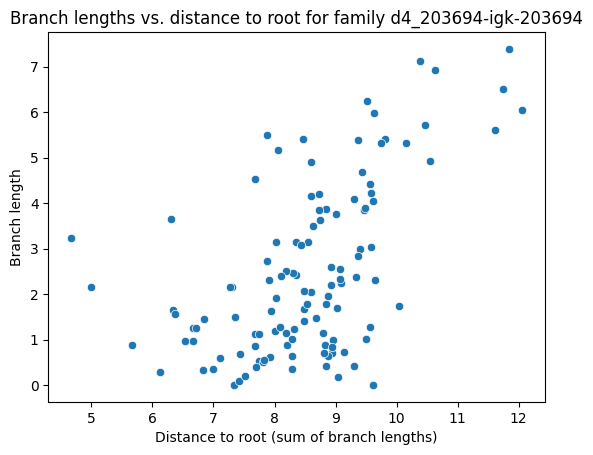

In [9]:
print(len(distances))
sns.scatterplot(edges_df, x="dist_to_root", y="branch_length")
plt.title(f"Branch lengths vs. distance to root for family {family}")
plt.xlabel("Distance to root (sum of branch lengths)")
plt.ylabel("Branch length")
plt.show()

In [10]:
# Calculate likelihood of leaves conditioned on the root and distance from root
import tempfile

def dataloader_from_transitions(transitions, batch_size=32, mask_prob=0.15):
    datafile = tempfile.NamedTemporaryFile(delete=False, suffix=".txt")
    with open(datafile.name, "w") as f:
        f.write("{0} transitions\n".format(len(transitions)))
        f.write("\n".join(transitions))

    dataset = EncodedPEINTDataset(
        dataset=CherriesDataset(data_file=datafile.name),
        vocab=vocab,
        mask_prob=mask_prob,
        random_token_prob=0.0,
        leave_unmasked_prob=0.0,
    )
    generator = iter(
        PLMRDataModule(
            dataset=dataset,
            batch_size=batch_size,
            shuffle=False,
        )._dataloader_template(dataset=dataset, training=False)
    )
    return generator

def infer_log_likelihoods(dataloader, module):
    # run inference on the dataloader
    lls = []
    for batch in tqdm(dataloader, desc="Inference"):
        batch = [b.to(device) for b in batch]
        [x, x_targets, y, y_targets, t, x_pad_mask, y_pad_mask] = batch
        yt_mask = y_targets != module.net.vocab.pad_idx  # actual values

        with torch.no_grad() and torch.autocast(device_type="cuda", dtype=torch.bfloat16):
            x_logits, y_logits = module(x, y, t, x_pad_mask, y_pad_mask)

        y_logits = y_logits - torch.logsumexp(y_logits, dim=-1, keepdim=True)
        y_logits = y_logits.transpose(-1, -2)
        nll = F.cross_entropy(y_logits, y_targets, ignore_index=vocab.pad_idx, reduction="none")

        ll = -nll * yt_mask.float()
        ll = ll.sum(dim=-1)
        lls.append(ll.detach().cpu().numpy())

    lls = np.concatenate(lls)
    return lls

In [11]:
leaf_df = edges_df[edges_df.is_leaf == True]
print(len(root_seq))

243


In [13]:
transitions = [
    f"{root_seq.strip()} {row.leaf_seq.strip()} {row.dist_to_root}" for _, row in leaf_df.iterrows()
]
dataloader = dataloader_from_transitions(transitions, batch_size=32)
print(f"Number of transitions: {len(transitions)}")
lls = infer_log_likelihoods(dataloader, module)
leaf_df['ll_leaf'] = lls

Number of transitions: 120


Inference:   0%|                                                                        | 0/4 [00:00<?, ?it/s]

Inference: 100%|████████████████████████████████████████████████████████████████| 4/4 [00:01<00:00,  3.81it/s]
/tmp/ipykernel_3276575/2944534430.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  leaf_df['ll_leaf'] = lls


## Using peint for ancestral reconstruction

Now let's look at the likelihood of the root sequence given the sequences at the leaves of the tree. For this, we will first naively evaluate the log-likelihood of the root sequence, given each individual leaf and the distance from the root.

In [14]:
transitions = [
    f"{row.leaf_seq.strip()} {root_seq.strip()} {row.dist_to_root}" for _, row in leaf_df.iterrows()
]
dataloader = dataloader_from_transitions(transitions, batch_size=32)
print(f"Number of transitions: {len(transitions)}")
lls = infer_log_likelihoods(dataloader, module)
leaf_df['ll_root'] = lls

Number of transitions: 120


Inference: 100%|████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 11.31it/s]
/tmp/ipykernel_3276575/3035527215.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  leaf_df['ll_root'] = lls


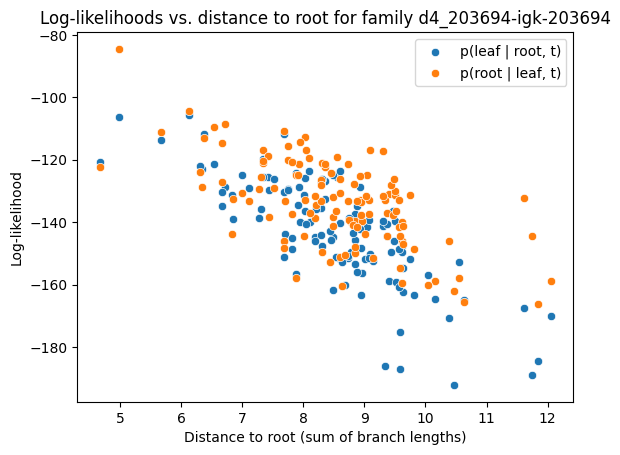

In [15]:
sns.scatterplot(leaf_df, x="dist_to_root", y="ll_leaf", label="p(leaf | root, t)")
sns.scatterplot(leaf_df, x="dist_to_root", y="ll_root", label="p(root | leaf, t)")
plt.title(f"Log-likelihoods vs. distance to root for family {family}")
plt.xlabel("Distance to root (sum of branch lengths)")
plt.ylabel("Log-likelihood")
plt.legend()
plt.show()

/tmp/ipykernel_3276575/675405191.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  leaf_df['ll_res'] = leaf_df['ll_root'] - leaf_df['ll_leaf']


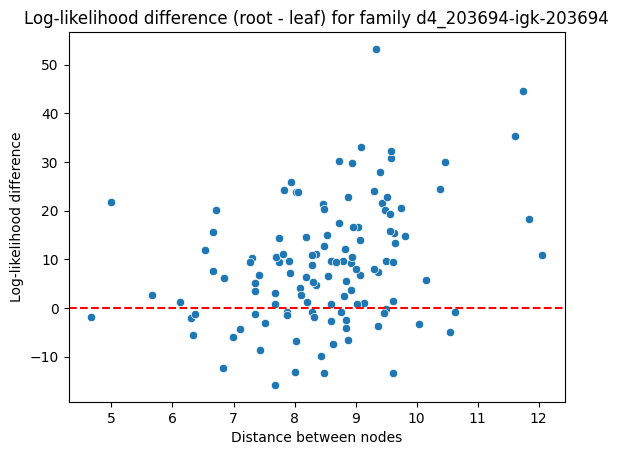

In [16]:
leaf_df['ll_res'] = leaf_df['ll_root'] - leaf_df['ll_leaf']
sns.scatterplot(leaf_df, x="dist_to_root", y="ll_res")
plt.title(f"Log-likelihood difference (root - leaf) for family {family}")
plt.xlabel("Distance between nodes")
plt.ylabel("Log-likelihood difference")
# add horizontal line at 0
plt.axhline(0, color='red', linestyle='--')
plt.show()

Interesting, we see that the model actually predicts a higher likelihood in the reverse direction p(root | leaf, t) than the forward direction on which it is trained p(leaf | root, t). This is perhaps due to the fact that conditioning on larger branch lengths along with the leaf sequence provides a lot of information about the "direction" of evolution, helping it pick out the root. Whereas in the forward direction, there are many more possible leaves that could have evolved from the root in the training data. 

## Sample "root" sequences conditioned on leaves and save to file

Now, let's simply sample some root sequences conditioned on the leaves and the distance from the root. We will later calculate quality, diversity, and novelty metrics on these "imagined" root sequences compared to the actual root sequence in this tree.

In [12]:
def remove_eos(seq):
    eos_idx = seq.find("<eos>")
    if eos_idx != -1:
        return seq[:eos_idx]
    return seq

In [13]:
transitions = [
    f"{row.leaf_seq.strip()} {root_seq.strip()} {row.dist_to_root}" for _, row in leaf_df.iloc[:5].iterrows()
]
dataloader = dataloader_from_transitions(transitions, batch_size=1, mask_prob=0.0)

max_length = max(1024, len(root_seq))
n_samples_per_leaf = 100
temperature = 1.0
top_p = 1.0
samples = {}

for idx, batch in tqdm(enumerate(dataloader), desc="Sampling sequences"):
    batch = [b.to(device) for b in batch]
    [x, x_targets, y, y_targets, t, x_pad_mask, y_pad_mask] = batch

    _x = x.repeat(n_samples_per_leaf, 1)
    _t = t.repeat(n_samples_per_leaf, 1)

    with torch.no_grad() and torch.autocast(device_type="cuda", dtype=torch.bfloat16):
        net: PEINT = module.net
        y_toks = net.generate(_x, _t, max_length, device, temperature, top_p)

    leaf_seq = leaf_df.iloc[idx].leaf_seq.strip()

    # y_seqs = vocab.decode(y_toks)
    # y_seqs = [remove_eos(seq) for seq in y_seqs]
    # samples[(leaf_seq, t.squeeze().item())] = y_seqs
    samples[leaf_seq] = y_toks

 24%|██████████████████████████████████████████████████                                                                                                                                                            | 249/1024 [00:03<00:11, 68.88it/s]
Sampling sequences: 5it [00:19,  3.91s/it]


In [ ]:
# save each set of sequences to a file where the first line is the leaf sequence and branch length
savedir = Path("/accounts/projects/yss/stephen.lu/protevo/plmr/results/zero_shot/peint")
savedir.mkdir(parents=True, exist_ok=True)
for (leaf_seq, t), seqs in samples.items():
    seqs = [remove_eos(seq) for seq in seqs]
    row = leaf_df[(leaf_df.leaf_seq == leaf_seq)].iloc[0]
    child_name = row.child_name
    filename = savedir / f"{child_name}.txt"
    with open(filename, "w") as f:
        f.write(f"{leaf_seq} {t}\n")
        for seq in seqs:
            f.write(f"{seq}\n")

## Infer likelihoods under PEINTDiff decoder

In [15]:
peintdiff_ckpt_path = ckpt_dir / "2025-08-13_00-29-36/checkpoints/epoch_035.ckpt"
peintdiff_module = load_peintdiff_from_checkpoint(peintdiff_ckpt_path, device)
vocab = peintdiff_module.net.vocab

/accounts/projects/yss/stephen.lu/protevo/plmr/plmr/models/frameworks/peint.py:94: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map

In [16]:
data_dir = Path("/accounts/projects/yss/stephen.lu/protevo/plmr/data/wyatt/indels")
data_file = data_dir / "edges_joint/d4.txt"

dataset = EncodedPEINTDiffDataset(
    dataset=CherriesDataset(data_file=data_file, cache_indices=False, min_t=5e-3, quantize_t=False),
    vocab=vocab,
)
setattr(dataset, "sampler", lambda: None)
dataloader = PLMRDataModule(
    dataset=dataset,
    batch_size=32,
    shuffle=False,
)._dataloader_template(dataset=dataset, training=False)

In [17]:
df_edges = pd.read_csv(data_dir / "peint_df.csv.gz", compression="gzip")
df_edges = df_edges[df_edges["sample_id"] == "d4"]
df_edges = df_edges[
    (df_edges.parent_heavy_aa != df_edges.child_heavy_aa)
    | (df_edges.parent_light_aa != df_edges.child_light_aa)
]
print(df_edges.shape)
print(len(dataloader)*32)

(9600, 48)
9600


In [18]:
lls_peintdiff = defaultdict(list)
lls_peint = defaultdict(list)

peintdiff_module.antithetic_sampling = False
_eps_ts = [0, 0.25, 0.5, 0.75, 1 - 1e-3]

for batch in tqdm(iter(dataloader), desc="Inference PEINTdiff"):
    batch = [b.to(device) for b in batch]
    [x, x_pad_mask, labeled, y_src, y_tgt, b, y_src_pad_mask] = batch
    yt_mask = y_tgt != peintdiff_module.net.vocab.pad_idx   # actual values

    for _eps_t in _eps_ts:
        xt, unet_conditioning, t, dsigma, sigma = peintdiff_module._forward_pass_diffusion_pre(
            x, _eps_t=_eps_t
        )

        # Infer with PEINTdiff
        with torch.no_grad() and torch.autocast(device_type="cuda", dtype=torch.bfloat16):
            x_logits, y_logits = peintdiff_module._model_wrapper(
                xt, x_pad_mask, unet_conditioning, y_src, y_src_pad_mask, b
            )
        y_logits = y_logits - torch.logsumexp(y_logits, dim=-1, keepdim=True)
        y_logits = y_logits.transpose(-1, -2)
        nll = F.cross_entropy(y_logits, y_tgt, ignore_index=vocab.pad_idx, reduction="none")
        ll = -nll * yt_mask.float()
        ll = ll.sum(dim=-1)
        lls_peintdiff[_eps_t].append(ll.detach().cpu().numpy())

        # # Infer with PEINT
        # with torch.no_grad() and torch.autocast(device_type="cuda", dtype=torch.bfloat16):
        #     x_logits, y_logits = module(
        #         xt, y_src, b, x_pad_mask, y_src_pad_mask
        #     )
        # y_logits = y_logits - torch.logsumexp(y_logits, dim=-1, keepdim=True)
        # y_logits = y_logits.transpose(-1, -2)
        # nll = F.cross_entropy(y_logits, y_tgt, ignore_index=vocab.pad_idx, reduction="none")
        # ll = -nll * yt_mask.float()
        # ll = ll.sum(dim=-1)
        # lls_peint[_eps_t].append(ll.detach().cpu().numpy())

lls_peintdiff = {k: np.concatenate(v) for k, v in lls_peintdiff.items()}
lls_peint = {k: np.concatenate(v) for k, v in lls_peint.items()}

for k, v in lls_peint.items():
    df_edges[f'll_peint_{k}'] = v
    
for k, v in lls_peintdiff.items():
    df_edges[f'll_peintdiff_{k}'] = v

Inference PEINTdiff: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 300/300 [02:05<00:00,  2.39it/s]


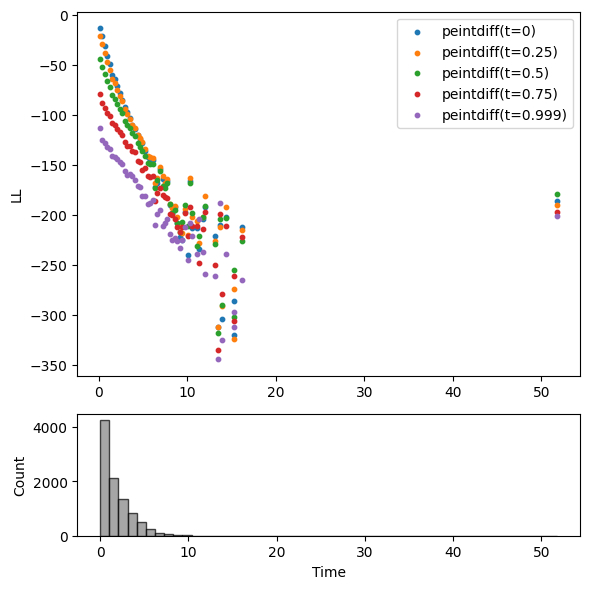

In [19]:
# plot the binned likelihoods according to the branch length
df_edges["time_bin"] = df_edges.branch_length // df_edges.branch_length.quantile(0.15).astype(float)
bin_cols = ["time_bin", "branch_length"] + [f"ll_peint_{k}" for k in lls_peint.keys()] + [f"ll_peintdiff_{k}" for k in lls_peintdiff.keys()]
binned_df = df_edges[bin_cols].groupby("time_bin").mean()

fig, (ax_main, ax_histx) = plt.subplots(2, 1, gridspec_kw={"height_ratios": [3, 1]}, figsize=(6, 6))

# Main scatter plot
for diff_t in list(lls_peint.keys()):
    ax_main.scatter(
        binned_df.branch_length, binned_df[f"ll_peint_{diff_t}"], label=f"peint(t={diff_t})", s=10
    )
    
for diff_t in list(lls_peintdiff.keys()):
    ax_main.scatter(
        binned_df.branch_length, binned_df[f"ll_peintdiff_{diff_t}"], label=f"peintdiff(t={diff_t})", s=10
    )

ax_main.set_ylabel("LL")
ax_main.legend()

# Histogram on x-axis showing distribution of actual time values
ax_histx.hist(df_edges.branch_length, bins=50, alpha=0.7, color="gray", edgecolor="black")
ax_histx.set_ylabel("Count")
ax_histx.set_xlabel("Time")

plt.tight_layout()
plt.show()

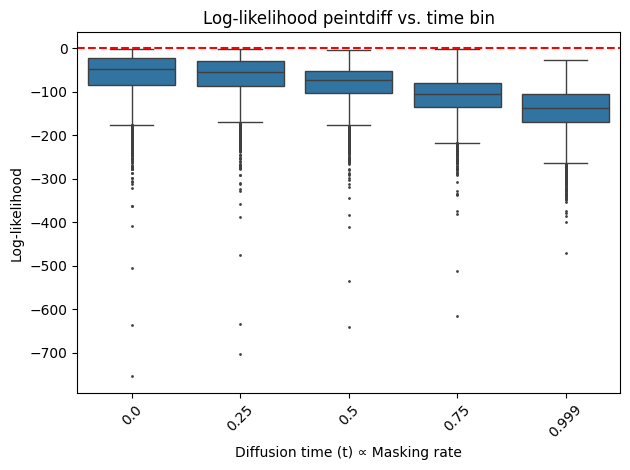

In [20]:
df_data = []

for _, row in df_edges.iterrows():
    for _eps_t in _eps_ts:
        df_data.append(
            {
                "branch_length": row.branch_length,
                "ll_peintdiff": row[f"ll_peintdiff_{_eps_t}"],
                "diff_t": _eps_t,
            }
        )

df_data = pd.DataFrame(df_data)
sns.boxplot(df_data, x="diff_t", y="ll_peintdiff", fliersize=1)
# add scatter point on top of the boxplot
# sns.stripplot(df_data, x="diff_t", y="ll_diff", color="black", alpha=0.5, size=2)
plt.title("Log-likelihood peintdiff vs. time bin")
plt.xlabel("Diffusion time (t) ∝ Masking rate")
plt.ylabel("Log-likelihood")
plt.xticks(rotation=45)
plt.axhline(0, color="red", linestyle="--")
plt.tight_layout()
plt.show()

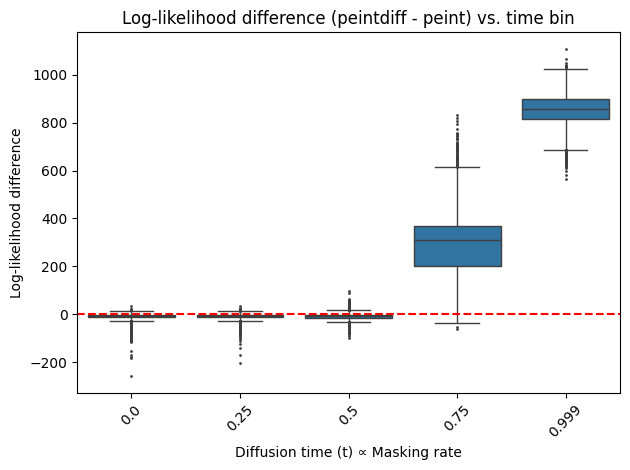

In [24]:
df_data = []

for _eps_t in _eps_ts:
    df_edges[f'll_diff_{_eps_t}'] = df_edges[f'll_peintdiff_{_eps_t}'] - df_edges[f'll_peint_{_eps_t}']

for _, row in df_edges.iterrows():
    for _eps_t in _eps_ts:
        df_data.append({
            "branch_length": row.branch_length,
            "ll_diff": row[f'll_diff_{_eps_t}'],
            "diff_t": _eps_t, 
        })

df_data = pd.DataFrame(df_data)
sns.boxplot(df_data, x="diff_t", y="ll_diff", fliersize=1)
# add scatter point on top of the boxplot
# sns.stripplot(df_data, x="diff_t", y="ll_diff", color="black", alpha=0.5, size=2)
plt.title("Log-likelihood difference (peintdiff - peint) vs. time bin")
plt.xlabel("Diffusion time (t) ∝ Masking rate")
plt.ylabel("Log-likelihood difference")
plt.xticks(rotation=45)
plt.axhline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

## Sample from the PEINTDiff encoder only p(x), no guidance

First, let's sample some sequences from the PEINTdiff diffusion encoder without any guidance. This will give us an idea of how well it managed to model the distribution of antibody sequences in the training data without any conditioning.

In [21]:
import gc
gc.collect()
torch.cuda.empty_cache()
# print available memory
print(f"Available memory: {torch.cuda.memory_reserved(device) / 1e9:.2f} GB")
print(f"Allocated memory: {torch.cuda.memory_allocated(device) / 1e9:.2f} GB")
print(f"Max memory allocated: {torch.cuda.max_memory_allocated(device) / 1e9:.2f} GB")
print(f"Max memory reserved: {torch.cuda.max_memory_reserved(device) / 1e9:.2f} GB")

Available memory: 17.14 GB
Allocated memory: 13.40 GB
Max memory allocated: 26.74 GB
Max memory reserved: 38.94 GB


In [22]:
from plmr.models.frameworks.mdlm import LogLinearNoise

seq_length = len(root_seq)
n_steps = seq_length

peintdiff_module.sampler = "ddpm"
peintdiff_module.noise = LogLinearNoise()

sampler = PEINTDiffSampler(
    net=peintdiff_module.net,
    mdlm=peintdiff_module,
    n_steps=n_steps,
    max_length=seq_length,
    batch_size=100,
)

diff_samples, traj = sampler._sample(return_traj=True)
diff_samples = vocab.decode(diff_samples)

Sampling...: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 243/243 [00:37<00:00,  6.45it/s]


In [ ]:
save_dir = Path("/accounts/projects/yss/stephen.lu/protevo/plmr/results/de_novo_unguided")
save_dir.mkdir(parents=True, exist_ok=True)

with open(save_dir / f"{seq_length}.txt", "w") as f:
    for seq in diff_samples:
        f.write(f"{seq}\n")

In [168]:
ppl_dict = {}
peint_ppl_dict = {}

for idx, row in leaf_df.iloc[:5].iterrows():
    leaf_seq = row.leaf_seq.strip()

    x = torch.from_numpy(vocab.encode(leaf_seq)).unsqueeze(0).to(device)
    b = torch.tensor([row.dist_to_root], device=device).unsqueeze(0)
    b = b.repeat(traj[0].shape[0], 1)
    x_pad_mask = x != vocab.pad_idx
    x, unet_conditioning, t, dsigma, sigma = peintdiff_module._forward_pass_diffusion_pre(
        x, _eps_t=0.0
    )
    y_peint = samples[leaf_seq]
    b_peint = torch.tensor([row.dist_to_root], device=device).unsqueeze(0).repeat(y_peint.shape[0], 1)
    with torch.no_grad() and torch.autocast(device_type="cuda", dtype=torch.bfloat16):
        ppls_ypeint = peintdiff_module.net.perplexity(x=x, t=b_peint, y=y_peint)
    ppls_ypeint = ppls_ypeint.detach().squeeze().cpu().numpy()

    # Infer LLs of trajectory with PEINTdiff
    ppls = []
    for yt in tqdm(traj):
        with torch.no_grad() and torch.autocast(device_type="cuda", dtype=torch.bfloat16):
            _ppl = peintdiff_module.net.perplexity(x=x, t=b, y=yt)
        ppls.append(_ppl.detach().squeeze().cpu().numpy())

    ppls = np.array(ppls)
    ppl_dict[leaf_seq] = ppls
    peint_ppl_dict[leaf_seq] = ppls_ypeint

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 245/245 [00:19<00:00, 12.62it/s]


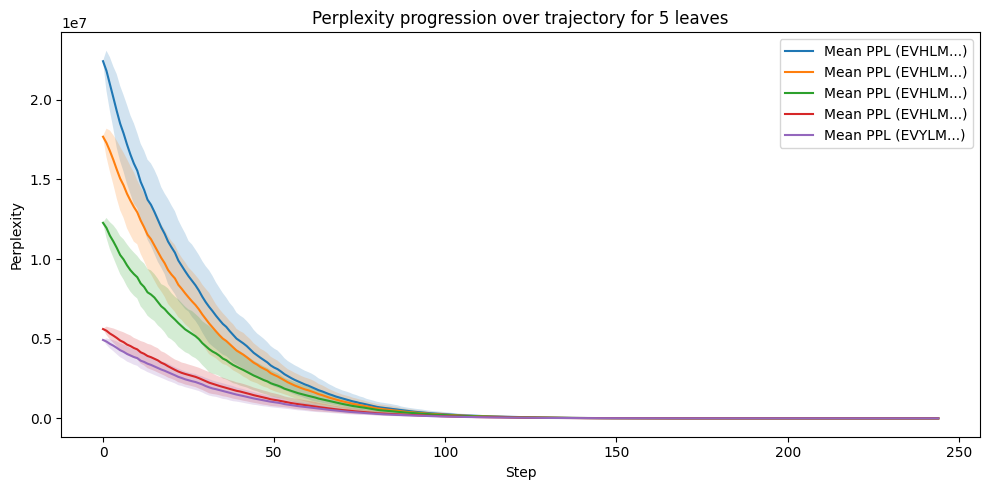

In [169]:
# Plot the progression of the perplexity (mean and std) over the trajectory
plt.figure(figsize=(10, 5))
colors = sns.color_palette("husl", len(ppl_dict))

for leaf_seq, ppls in ppl_dict.items():
    df = pd.DataFrame({
        "step": np.arange(len(ppls)),
        "ppl_mean": ppls.mean(axis=1),
        "ppl_std": ppls.std(axis=1),
    })
    sns.lineplot(df, x="step", y="ppl_mean", label=f"Mean PPL ({leaf_seq[:5]}...)")
    # add shaded area for standard deviation
    plt.fill_between(
        df["step"],
        df["ppl_mean"] - df["ppl_std"],
        df["ppl_mean"] + df["ppl_std"],
        alpha=0.2,
    )

plt.title(f"Perplexity progression over trajectory for 5 leaves")
plt.xlabel("Step")
plt.ylabel("Perplexity")
plt.legend()
plt.tight_layout()
plt.show()

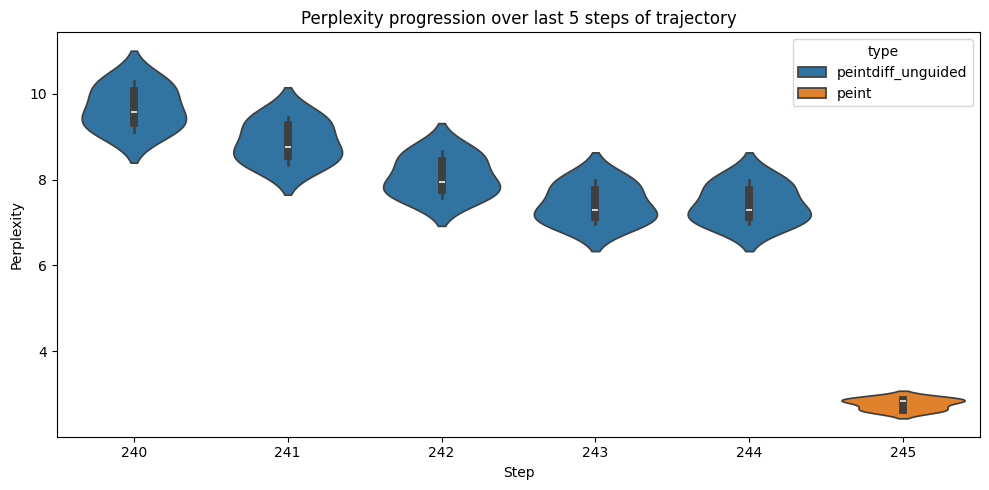

In [170]:
# Plot the perplexities of the last 5 steps of each trajectory
plt.figure(figsize=(10, 5))
colors = sns.color_palette("husl", len(ppl_dict))

data = []
for leaf_seq, ppls in ppl_dict.items():
    for i in range(len(ppls)-5, len(ppls)):
        data.append({
            "type": "peintdiff_unguided",
            "leaf_seq": leaf_seq,
            "step": i,
            "ppl": ppls.mean(axis=1)[i],
        })
    peint_ppls = peint_ppl_dict[leaf_seq]
    data.append({
        "type": "peint",
        "leaf_seq": leaf_seq,
        "step": i+1,
        "ppl": peint_ppls.mean(),
    })

df = pd.DataFrame(data)

sns.violinplot(df, x="step", y="ppl", hue="type")
plt.title(f"Perplexity progression over last 5 steps of trajectory")
plt.xlabel("Step")
plt.ylabel("Perplexity")
plt.tight_layout()
plt.show()

## Sample root sequences conditioned on leaves using PEINTDiff and save to file

Now, similarly to what I did previously with the PEINT model, i will sample from `p(root | leaf, t)` using the PEINTDiff model with hidden state guidance. This will give us a set of "imagined" root sequences that we can compare to the samples obtained via the PEINT model.

In [173]:
seq_length = len(root_seq)
n_steps = seq_length // 2
n_samples_per_leaf = 20
guided_samples = defaultdict(list)

sampler = PEINTDiffLangevinSampler(
    net=peintdiff_module.net,
    mdlm=peintdiff_module,
    n_steps=n_steps,
    max_length=seq_length,
    batch_size=n_samples_per_leaf,
    langevin_steps=64,
    lambda_z = 0.0,
    lambda_x = 0.0,
)

langevin_samples = []
langevin_trajs = []

for idx, row in leaf_df.iloc[:2].iterrows():
    leaf_seq = row.leaf_seq.strip()

    y = torch.from_numpy(vocab.encode(leaf_seq)).unsqueeze(0).to(device)
    lambda_y = torch.ones(y.shape[0], device=device).unsqueeze(0).to(device)
    t = torch.tensor([row.dist_to_root], device=device).unsqueeze(0).to(device)

    sampler.update_guidance_params(y=y, t=t, lambda_y=lambda_y)
    y_seqs, y_traj = sampler._sample(return_traj=True)
    y_seqs = vocab.decode(y_seqs)
    langevin_samples.append(y_seqs)
    langevin_trajs.append(y_traj)

Sampling...: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 121/121 [01:19<00:00,  1.52it/s]


In [174]:
# infer likelihoods of the langevin samples and compare to unguided peintdiff and vanilla peint samples
guided_ppl_dict = {}

for idx, (_, row) in enumerate(leaf_df.iloc[:5].iterrows()):
    leaf_seq = row.leaf_seq.strip()

    x = torch.from_numpy(vocab.encode(leaf_seq)).unsqueeze(0).to(device)
    b = torch.tensor([row.dist_to_root], device=device).unsqueeze(0)
    b = b.repeat(langevin_trajs[idx][0].shape[0], 1)
    x_pad_mask = x != vocab.pad_idx
    x, unet_conditioning, t, dsigma, sigma = peintdiff_module._forward_pass_diffusion_pre(
        x, _eps_t=0.0
    )

    # Infer LLs of trajectory with PEINTdiff
    guided_ppls = []
    for yt in tqdm(langevin_trajs[idx]):
        with torch.no_grad() and torch.autocast(device_type="cuda", dtype=torch.bfloat16):
            _ppl = peintdiff_module.net.perplexity(x=x, t=b, y=yt)
        guided_ppls.append(_ppl.detach().squeeze().cpu().numpy())

    guided_ppl_dict[leaf_seq] = np.array(guided_ppls)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 123/123 [00:07<00:00, 16.43it/s]


IndexError: list index out of range

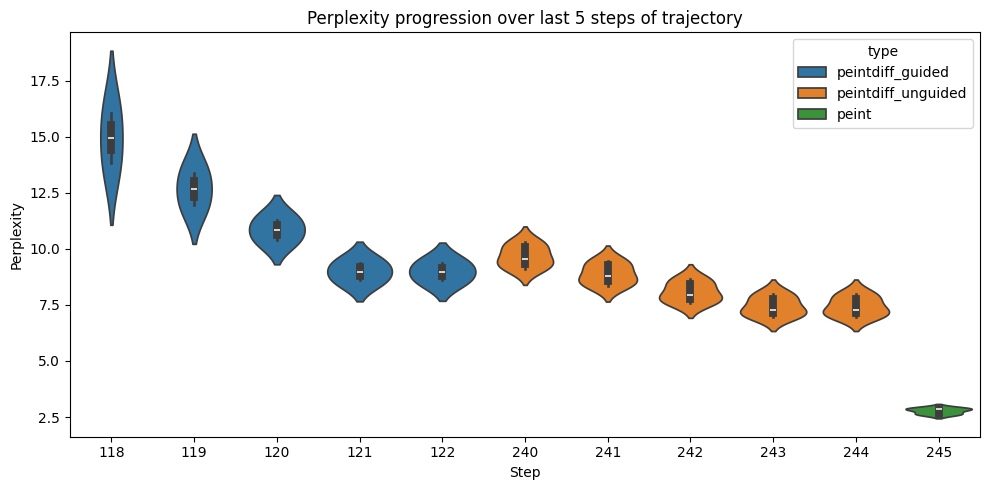

In [176]:
# Plot the perplexities of the last 5 steps of each trajectory
plt.figure(figsize=(10, 5))
colors = sns.color_palette("husl", len(ppl_dict))

data = []
for leaf_seq, ppls in ppl_dict.items():
    for i in range(len(ppls) - 5, len(ppls)):
        data.append(
            {
                "type": "peintdiff_unguided",
                "leaf_seq": leaf_seq,
                "step": i,
                "ppl": ppls.mean(axis=1)[i],
            }
        )

    peint_ppls = peint_ppl_dict[leaf_seq]
    data.append(
        {
            "type": "peint",
            "leaf_seq": leaf_seq,
            "step": i + 1,
            "ppl": peint_ppls.mean(),
        }
    )

    guided_ppls = guided_ppl_dict.get(leaf_seq)
    if guided_ppls is not None:
        for i in range(len(guided_ppls) - 5, len(guided_ppls)):
            data.append(
                {
                    "type": "peintdiff_guided",
                    "leaf_seq": leaf_seq,
                    "step": i,
                    "ppl": guided_ppls.mean(axis=1)[i],
                }
            )

df = pd.DataFrame(data)

sns.violinplot(df, x="step", y="ppl", hue="type")
plt.title(f"Perplexity progression over last 5 steps of trajectory")
plt.xlabel("Step")
plt.ylabel("Perplexity")
plt.tight_layout()
plt.show()